# 📈 LỚP 1: TỐI ƯU HÓA CỖ MÁY BÁN HÀNG - PHÂN CỤM ĐƠN HÀNG (CLUSTERING)

Đây là file triển khai code bài bản cho Khâu 1 của dự án Data Mining. 

**Mục tiêu kinh doanh:** Khám phá cấu trúc tự nhiên của danh mục đơn hàng bán ra dựa trên đặc tính Sản Phẩm (`Gia` và `TrongLuong`), để từ đó phân loại và tạo chiến lược logistics/marketing cho từng phân khúc chuyên biệt.

---
### Quy trình chuẩn (Có Kiểm thử Validation)
1. **Load data & Verify:** Chắc chắn dữ liệu > 40k dòng và không bị mất mát.
2. **Tiền xử lý (Preprocessing):** Log-Transform để xử lý Outliers và Chuẩn hóa (Standarization).
3. **Tối ưu Hyperparameter (Tìm K):** Dùng biểu đồ phân tích phương sai (Elbow) và độ cô lập cụm (Silhouette).
4. **Triển khai mô hình K-Means:** Phân cụm mảng đơn hàng hiện tại.
5. **Xuất báo cáo & Dữ liệu:** Gửi sang cho Layer 2 (Anomaly Detection).

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings("ignore")

# Thiết lập hiển thị đồ hoạ tinh tế hơn
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Đã tải xong các thư viện cốt lõi.")

✅ Đã tải xong các thư viện cốt lõi.


In [16]:
%pip install --upgrade threadpoolctl scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 1. Load Data và Khởi tạo Dataframe
Đảm bảo file `orders_for_mining.csv` được đặt đúng tại thư mục `../data/`.

In [16]:
file_path = '../data/orders_for_mining.csv'
try:
    df = pd.read_csv(file_path)
    print(f"✅ Tải dữ liệu thành công! Tổng số dòng: {len(df):,}")
except FileNotFoundError:
    print("❌ LỖI NGHIÊM TRỌNG: Không tìm thấy file csv. Hãy kiểm tra lại đường dẫn.")

# [TEST CASE] Verify dữ liệu không bị hụt
assert len(df) > 40000, "Lỗi: Dữ liệu tải lên ít hơn 40.000 dòng. Cần kiểm tra lại khâu Export từ Oracle."
assert 'GIA' in df.columns.str.upper(), "Lỗi: Không tìm thấy cột GIA"
assert 'TRONGLUONG' in df.columns.str.upper(), "Lỗi: Không tìm thấy cột TRONGLUONG"

# Đồng nhất tên cột chữ hoa để dễ kiểm soát
df.columns = df.columns.str.upper()
df.head()

✅ Tải dữ liệu thành công! Tổng số dòng: 47,818


,MADON,MAMH,GIA,TRONGLUONG,TONGTIEN,SOLUONGDAT,KENHBANHANG,QUY,THUTRONGTUAN,BANG,LOAICUAHANG,MACUAHANG
0,10223,15595,19.20,100,19.20,1,Truc tuyen,3,Tuesday,MG,Truc tuyen,OL_3
1,10224,8189,110.90,800,110.90,1,Tai cua hang,4,Monday,SP,Vat ly,38
2,10225,1243,29.89,300,29.89,1,Tai cua hang,2,Wednesday,BA,Vat ly,33
3,10226,1840,58.99,1550,58.99,1,Tai cua hang,2,Friday,SP,Vat ly,25
4,10227,16848,169.99,3950,169.99,1,Truc tuyen,3,Tuesday,BA,Truc tuyen,OL_22


## 2. Tiền xử lý (Data Preprocessing)
Như khảo sát từ Oracle, cột `TRONGLUONG` có vài bản ghi mang giá trị 0g và cột `GIA` lệch phải nghiêm trọng (Right-skewed). 
Thuật toán K-Means sư dụng khoảng cách Euclidean, nên outliers rất dễ bóp méo Centroids. Cần xử lý bằng Log-Transform.

ℹ️ Phát hiện 0 đơn hàng có trọng lượng = 0g. Thay thế bằng 1g để tránh lỗi thuật toán.


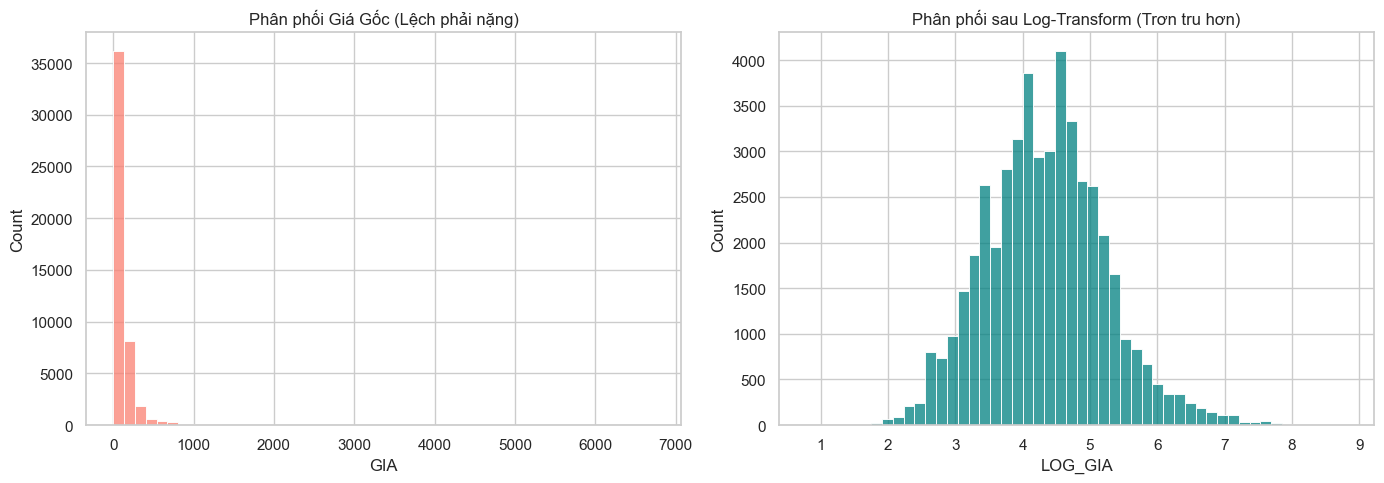

In [17]:
# Xử lý trọng lượng = 0 trước khi Log.
zero_weight_count = len(df[df['TRONGLUONG'] == 0])
print(f"ℹ️ Phát hiện {zero_weight_count} đơn hàng có trọng lượng = 0g. Thay thế bằng 1g để tránh lỗi thuật toán.")
df['TRONGLUONG'] = df['TRONGLUONG'].replace(0, 1)

# Log-transform (Dùng log1p để an toàn tính log(1+x))
df['LOG_GIA'] = np.log1p(df['GIA'])
df['LOG_TRONGLUONG'] = np.log1p(df['TRONGLUONG'])

# [VERIFY TRỰC QUAN]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['GIA'], bins=50, ax=axes[0], color='salmon')
axes[0].set_title("Phân phối Giá Gốc (Lệch phải nặng)")

sns.histplot(df['LOG_GIA'], bins=50, ax=axes[1], color='teal')
axes[1].set_title("Phân phối sau Log-Transform (Trơn tru hơn)")
plt.tight_layout()
plt.show()

### Chuẩn hóa (Standarization)

Đưa Features về cùng một Scale `(Mean = 0, Std = 1)`

In [18]:
from sklearn.preprocessing import StandardScaler

features = ['LOG_GIA', 'LOG_TRONGLUONG']
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# [TEST CASE] Kiểm tra sau StandardScaler
mean_val = np.abs(X_scaled.mean())
std_val = X_scaled.std()
assert mean_val < 0.01, f"Scale thất bại: Mean không xấp xỉ 0 (Mean={mean_val})"
assert np.abs(std_val - 1.0) < 0.01, f"Scale thất bại: Std không xấp xỉ 1 (Std={std_val})"
print("✅ Standard Scaler áp dụng thành công. Mean ≈ 0 và Std ≈ 1.")

✅ Standard Scaler áp dụng thành công. Mean ≈ 0 và Std ≈ 1.


## 3. Lựa chọn Siêu tham số K (Elbow & Silhouette)
Phần code này sẽ mất khoảng 10-30 giây tuỳ máy do phải thử nhiều biến thể K.

Đang tính toán Elbow và Silhouette. Xin trân trọng kiên nhẫn đợi (có thể tốn 10 - 20s)...
✅ Hoàn tất tính toán!


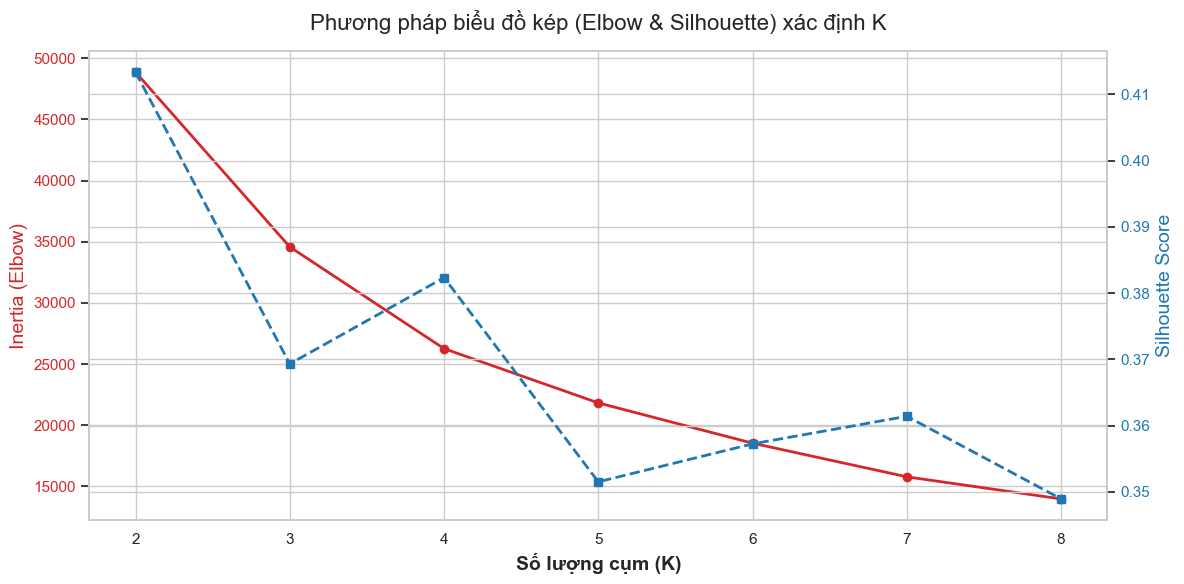

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

inertias = []
sil_scores = []
K_range = range(2, 9)

print("Đang tính toán Elbow và Silhouette. Xin trân trọng kiên nhẫn đợi (có thể tốn 10 - 20s)...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    # Sample data để tính Silhouette nhanh hơn nếu máy yếu
    sil_scores.append(silhouette_score(X_scaled, labels))
    
print("✅ Hoàn tất tính toán!")

# Vẽ 2 biểu đồ so sánh
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Số lượng cụm (K)', fontsize=14, weight='bold')
ax1.set_ylabel('Inertia (Elbow)', color=color, fontsize=14)
ax1.plot(K_range, inertias, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=14)  
ax2.plot(K_range, sil_scores, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Phương pháp biểu đồ kép (Elbow & Silhouette) xác định K', fontsize=16, pad=15)
fig.tight_layout()  
plt.show()

### YÊU CẦU TỪ AI (Antigravity) DÀNH CHO USER:
> BẠN HÃY XEM XÉT BIỂU ĐỒ TRÊN, XÁC NHẬN SỐ K BẠN MUỐN CHẠY SAU KHI PHÂN TÍCH ĐIỂM GÃY KHUỶU TAY BẰNG MẮT VÀ SAU ĐÓ CHẠY Ô CODE BÊN DƯỚI.

🚀 Chạy thuật toán chính thức K-Means với K = 4


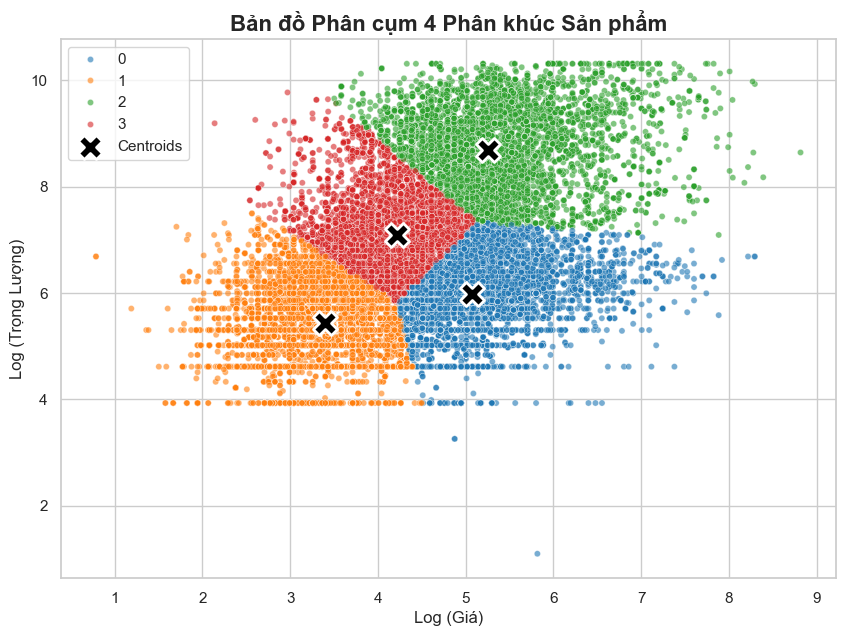


🔍 THỐNG KÊ CHI TIẾT TỪNG CỤM ĐỂ ĐẶT NHÃN (Dựa trên thông số Trung Vị - Median):


,GIA,TRONGLUONG,SO_LUONG_DON,TY_LE_%
CLUSTER,,,,
0,146.0,400.0,9800,20.49
1,29.9,225.0,14728,30.80
2,167.0,6272.5,8768,18.34
3,69.0,1200.0,14522,30.37


In [20]:
# [USER YÊU CẦU ĐỔI K TẠI ĐÂY NẾU CẦN]
OPTIMAL_K = 4 

print(f"🚀 Chạy thuật toán chính thức K-Means với K = {OPTIMAL_K}")
final_kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
df['CLUSTER'] = final_kmeans.fit_predict(X_scaled)

# Trực quan hoá Scatter
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df['LOG_GIA'], 
    y=df['LOG_TRONGLUONG'], 
    hue=df['CLUSTER'], 
    palette="tab10", 
    alpha=0.6, 
    s=20
)

# Đánh dấu Toạ độ trọng tâm (Centroids)
centroids = scaler.inverse_transform(final_kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='X', label='Centroids', edgecolors='white', linewidths=2)

plt.title(f'Bản đồ Phân cụm {OPTIMAL_K} Phân khúc Sản phẩm', fontsize=16, weight='bold')
plt.xlabel('Log (Giá)')
plt.ylabel('Log (Trọng Lượng)')
plt.legend()
plt.show()

# In báo cáo tóm tắt Cụm để người quản trị đặt tên (Business Labels)
print("\n🔍 THỐNG KÊ CHI TIẾT TỪNG CỤM ĐỂ ĐẶT NHÃN (Dựa trên thông số Trung Vị - Median):")
stats = df.groupby('CLUSTER')[['GIA', 'TRONGLUONG']].median().round(2)
stats['SO_LUONG_DON'] = df['CLUSTER'].value_counts()
stats['TY_LE_%'] = (df['CLUSTER'].value_counts(normalize=True) * 100).round(2)
display(stats)

## 4. Xuất Báo Cáo
Các thông tin Cụm đã được gán nhãn cho từng phần tử sẽ được xuất ra CSV mới (Layer 2 Anomaly Detection sẽ tái ứng dụng cột này để check bất thường nội cụm).

In [21]:
output_path = '../data/orders_with_clusters.csv'
df.to_csv(output_path, index=False)
print(f"✅ Đã xuất {len(df)} dòng sang file: {output_path}. Tích hợp sẵn cột 'CLUSTER'.")

✅ Đã xuất 47818 dòng sang file: ../data/orders_with_clusters.csv. Tích hợp sẵn cột 'CLUSTER'.
